# 04 — Baseline Model Comparison

**Project:** Pedi-CGAM Lite  
**Stage:** Round-1 backbone screening comparison  
**Models:** ResNet50, DenseNet121, EfficientNet-B0, ConvNeXt-Tiny, Swin-Tiny

This notebook does **no model training**.

It verifies that all available baseline outputs came from the same frozen Stage 02 split and then creates the final Round-1 comparison tables and figures.

## Selection philosophy

The research task is extremely imbalanced, so backbone selection is **not based on accuracy**.

We consider:

1. **14-pathology Macro-AUPRC** — primary screening metric
2. **Tail Macro-AUPRC** — especially important for Pedi-CGAM's long-tail objective
3. **14-pathology Macro-AUROC**
4. Macro-F1 / sensitivity at the common fixed 0.5 screening threshold
5. Training stability, GPU memory, and runtime

A small difference in validation Macro-AUPRC is not treated as statistical proof that one model is universally superior, especially because the rarest validation classes contain only one or a few positives.

### Expected Round-1 experiments

- `B01_ResNet50`
- `B02_DenseNet121`
- `B03_EfficientNetB0`
- `B04_ConvNeXtTiny`
- `B05_SwinTiny`

### Kaggle input

Attach the saved outputs (or output ZIPs) for all five baseline notebooks.

The notebook auto-discovers their `config.json`, metric CSVs, and environment files.

### Final Kaggle ZIP

`/kaggle/working/PediCGAM_Stage04_Baseline_Comparison_All_Outputs.zip`


In [1]:
# ============================================================
# 1. Imports and constants
# ============================================================
import os
import json
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KAGGLE_INPUT = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/PediCGAM/stage04_baseline_comparison")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPECTED_EXPERIMENTS = {
    "B01_ResNet50": "ResNet50",
    "B02_DenseNet121": "DenseNet121",
    "B03_EfficientNetB0": "EfficientNet-B0",
    "B04_ConvNeXtTiny": "ConvNeXt-Tiny",
    "B05_SwinTiny": "Swin-Tiny",
}

EXPECTED_SPLIT_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

print("Expected experiments:")
for k,v in EXPECTED_EXPERIMENTS.items():
    print(f"- {k}: {v}")


Expected experiments:
- B01_ResNet50: ResNet50
- B02_DenseNet121: DenseNet121
- B03_EfficientNetB0: EfficientNet-B0
- B04_ConvNeXtTiny: ConvNeXt-Tiny
- B05_SwinTiny: Swin-Tiny


In [2]:
# ============================================================
# 2. Extract candidate ZIP files if necessary
# ============================================================
EXTRACT_ROOT = Path("/kaggle/working/stage04_extracted_inputs")
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

zip_count = 0

for zp in KAGGLE_INPUT.rglob("*.zip"):
    name = zp.name.lower()
    if any(exp.lower() in name for exp in EXPECTED_EXPERIMENTS):
        target = EXTRACT_ROOT / zp.stem
        if not target.exists():
            target.mkdir(parents=True, exist_ok=True)
            try:
                with zipfile.ZipFile(zp, "r") as z:
                    z.extractall(target)
                zip_count += 1
                print("Extracted:", zp)
            except zipfile.BadZipFile:
                print("Skipped bad ZIP:", zp)

print("\nBaseline ZIPs extracted:", zip_count)


Extracted: /kaggle/input/notebooks/kalloldaskushol/03c-baseline-efficientnetb0/B03_EfficientNetB0_All_Outputs.zip
Extracted: /kaggle/input/notebooks/kalloldaskushol/03e-baseline-swintiny/B05_SwinTiny_All_Outputs.zip
Extracted: /kaggle/input/notebooks/kalloldaskushol/03a-baseline-resnet50/B01_ResNet50_All_Outputs.zip
Extracted: /kaggle/input/notebooks/kalloldaskushol/03b-baseline-densenet121/B02_DenseNet121_All_Outputs.zip
Extracted: /kaggle/input/notebooks/kalloldaskushol/03d-baseline-convnexttiny/B04_ConvNeXtTiny_All_Outputs.zip

Baseline ZIPs extracted: 5


In [3]:
# ============================================================
# 3. Discover experiment output directories from config.json
# ============================================================
SEARCH_ROOTS = [KAGGLE_INPUT, EXTRACT_ROOT]

discovered = {}

for root in SEARCH_ROOTS:
    for config_path in root.rglob("config.json"):
        try:
            cfg = json.loads(config_path.read_text())
        except Exception:
            continue

        exp_id = cfg.get("experiment_id")
        if exp_id in EXPECTED_EXPERIMENTS:
            # Prefer the first valid occurrence.
            if exp_id not in discovered:
                discovered[exp_id] = {
                    "root": config_path.parent,
                    "config_path": config_path,
                    "config": cfg,
                }

print("Discovered experiments:")
for exp_id in EXPECTED_EXPERIMENTS:
    if exp_id in discovered:
        print("✅", exp_id, "->", discovered[exp_id]["root"])
    else:
        print("❌", exp_id)

missing = [x for x in EXPECTED_EXPERIMENTS if x not in discovered]

if missing:
    raise FileNotFoundError(
        "Missing baseline outputs: "
        + ", ".join(missing)
        + ". Attach all five saved notebook outputs or output ZIPs."
    )

print("\n✅ All five baseline experiments discovered.")


Discovered experiments:
✅ B01_ResNet50 -> /kaggle/input/notebooks/kalloldaskushol/03a-baseline-resnet50/PediCGAM/B01_ResNet50
✅ B02_DenseNet121 -> /kaggle/input/notebooks/kalloldaskushol/03b-baseline-densenet121/PediCGAM/B02_DenseNet121
✅ B03_EfficientNetB0 -> /kaggle/input/notebooks/kalloldaskushol/03c-baseline-efficientnetb0/PediCGAM/B03_EfficientNetB0
✅ B04_ConvNeXtTiny -> /kaggle/input/notebooks/kalloldaskushol/03d-baseline-convnexttiny/PediCGAM/B04_ConvNeXtTiny
✅ B05_SwinTiny -> /kaggle/input/notebooks/kalloldaskushol/03e-baseline-swintiny/PediCGAM/B05_SwinTiny

✅ All five baseline experiments discovered.


In [4]:
# ============================================================
# 4. Verify fair-comparison configuration
# ============================================================
verification_rows = []

for exp_id, info in discovered.items():
    cfg = info["config"]

    checks = {
        "split_sha256": cfg.get("split_manifest_sha256") == EXPECTED_SPLIT_SHA256,
        "image_size_224": int(cfg.get("image_size", -1)) == 224,
        "loss_BCE": cfg.get("loss") == "BCEWithLogitsLoss",
        "batch_size_16": int(cfg.get("batch_size", -1)) == 16,
        "seed_42": int(cfg.get("seed", -1)) == 42,
        "train_5408": int(cfg.get("train_images", -1)) == 5408,
        "validation_1159": int(cfg.get("validation_images", -1)) == 1159,
        "calibration_not_used": cfg.get("calibration_used") is False,
        "official_test_not_used": cfg.get("official_test_used") is False,
    }

    verification_rows.append({
        "experiment_id": exp_id,
        "backbone": EXPECTED_EXPERIMENTS[exp_id],
        **checks,
        "all_fairness_checks_pass": all(checks.values()),
    })

verification_df = pd.DataFrame(verification_rows).sort_values("experiment_id")
display(verification_df)

verification_df.to_csv(
    TABLE_DIR / "baseline_fairness_verification.csv",
    index=False
)

if not verification_df["all_fairness_checks_pass"].all():
    raise RuntimeError(
        "At least one baseline configuration differs from the frozen "
        "Round-1 protocol. Do not compare models until reviewed."
    )

print("✅ All five experiments satisfy the fair-comparison gate.")


,experiment_id,backbone,split_sha256,image_size_224,loss_BCE,batch_size_16,seed_42,train_5408,validation_1159,calibration_not_used,official_test_not_used,all_fairness_checks_pass
2,B01_ResNet50,ResNet50,True,True,True,True,True,True,True,True,True,True
3,B02_DenseNet121,DenseNet121,True,True,True,True,True,True,True,True,True,True
0,B03_EfficientNetB0,EfficientNet-B0,True,True,True,True,True,True,True,True,True,True
4,B04_ConvNeXtTiny,ConvNeXt-Tiny,True,True,True,True,True,True,True,True,True,True
1,B05_SwinTiny,Swin-Tiny,True,True,True,True,True,True,True,True,True,True


✅ All five experiments satisfy the fair-comparison gate.


In [5]:
# ============================================================
# 5. Load metrics and environment information
# ============================================================
def read_metric_csv(path):
    df = pd.read_csv(path)
    if {"metric", "value"}.issubset(df.columns):
        return dict(zip(df["metric"], df["value"]))
    raise ValueError(f"Unexpected summary metric format: {path}")

rows = []

for exp_id in EXPECTED_EXPERIMENTS:
    info = discovered[exp_id]
    root = info["root"]
    cfg = info["config"]

    summary_path = root / "tables" / "summary_metrics.csv"
    hmt_path = root / "tables" / "head_middle_tail_metrics.csv"
    env_path = root / "environment_info.json"

    if not summary_path.exists():
        raise FileNotFoundError(summary_path)
    if not hmt_path.exists():
        raise FileNotFoundError(hmt_path)
    if not env_path.exists():
        raise FileNotFoundError(env_path)

    summary = read_metric_csv(summary_path)
    hmt = pd.read_csv(hmt_path)
    env = json.loads(env_path.read_text())

    group_map = dict(zip(hmt["group"], hmt["macro_AUPRC"]))

    rows.append({
        "experiment_id": exp_id,
        "backbone": EXPECTED_EXPERIMENTS[exp_id],
        "macro_AUPRC_14": float(summary["pathology14_macro_AUPRC"]),
        "head_macro_AUPRC": float(group_map["Head"]),
        "middle_macro_AUPRC": float(group_map["Middle"]),
        "tail_macro_AUPRC": float(group_map["Tail"]),
        "macro_AUROC_14": float(summary["pathology14_macro_AUROC"]),
        "macro_F1_at_0.5": float(summary["pathology14_macro_F1_at_0.5"]),
        "macro_sensitivity_at_0.5": float(
            summary["pathology14_macro_sensitivity_at_0.5"]
        ),
        "macro_specificity_at_0.5": float(
            summary["pathology14_macro_specificity_at_0.5"]
        ),
        "macro_balanced_accuracy_at_0.5": float(
            summary["pathology14_macro_balanced_accuracy_at_0.5"]
        ),
        "best_epoch": int(env["best_epoch"]),
        "training_minutes": float(env["training_minutes"]),
        "peak_gpu_memory_gb": float(env["peak_gpu_memory_gb"]),
    })

comparison = pd.DataFrame(rows)

comparison["rank_macro_AUPRC"] = (
    comparison["macro_AUPRC_14"]
    .rank(method="min", ascending=False)
    .astype(int)
)
comparison["rank_tail_AUPRC"] = (
    comparison["tail_macro_AUPRC"]
    .rank(method="min", ascending=False)
    .astype(int)
)
comparison["rank_macro_AUROC"] = (
    comparison["macro_AUROC_14"]
    .rank(method="min", ascending=False)
    .astype(int)
)

comparison = comparison.sort_values(
    ["rank_macro_AUPRC", "rank_tail_AUPRC"]
).reset_index(drop=True)

display(comparison)

comparison.to_csv(
    TABLE_DIR / "all_five_baseline_comparison.csv",
    index=False
)


,experiment_id,backbone,macro_AUPRC_14,head_macro_AUPRC,middle_macro_AUPRC,tail_macro_AUPRC,macro_AUROC_14,macro_F1_at_0.5,macro_sensitivity_at_0.5,macro_specificity_at_0.5,macro_balanced_accuracy_at_0.5,best_epoch,training_minutes,peak_gpu_memory_gb,rank_macro_AUPRC,rank_tail_AUPRC,rank_macro_AUROC
0,B01_ResNet50,ResNet50,0.175837,0.213555,0.259615,0.023966,0.805140,0.017369,0.010217,0.999476,0.504847,4,4.239826,1.020235,1,1,2
1,B02_DenseNet121,DenseNet121,0.147094,0.232309,0.177546,0.002511,0.751947,0.007635,0.004023,0.999732,0.501877,1,3.548770,1.125325,2,5,4
2,B03_EfficientNetB0,EfficientNet-B0,0.139150,0.215505,0.163086,0.013787,0.848101,0.028619,0.020183,0.999025,0.509604,4,3.931659,0.750431,3,2,1
3,B04_ConvNeXtTiny,ConvNeXt-Tiny,0.116493,0.229026,0.092672,0.005601,0.767974,0.009505,0.005065,0.999549,0.502307,3,4.754820,1.324220,4,4,3
4,B05_SwinTiny,Swin-Tiny,0.106372,0.161385,0.131425,0.006288,0.721599,0.000000,0.000000,1.000000,0.500000,1,4.284832,1.452550,5,3,5


## Important selection note

A strict ranking by the primary metric alone will place the two highest **Macro-AUPRC** models first.

However, Pedi-CGAM's scientific objective is explicitly long-tail pediatric classification. Therefore, the final Round-2 shortlist should also consider **Tail Macro-AUPRC** and overall ranking quality.

The notebook reports both:

- **Strict primary-metric top two**
- **Project-aligned recommended finalists**

This avoids hiding the trade-off.


In [6]:
# ============================================================
# 6. Strict primary ranking and project-aligned recommendation
# ============================================================
strict_top2 = (
    comparison.sort_values("macro_AUPRC_14", ascending=False)
    .head(2)[["experiment_id", "backbone", "macro_AUPRC_14"]]
    .copy()
)

print("STRICT TOP-2 BY 14-PATHOLOGY MACRO-AUPRC")
display(strict_top2)

# Frozen project-aligned decision:
# ResNet50 clearly wins primary Macro-AUPRC and tail AUPRC.
# For the second finalist, EfficientNet-B0 is selected over DenseNet121
# because the Macro-AUPRC gap is modest while EfficientNet-B0 shows
# materially better tail AUPRC, macro-AUROC, F1, sensitivity, and GPU memory.
RECOMMENDED_FINALISTS = ["B01_ResNet50", "B03_EfficientNetB0"]

recommended = comparison[
    comparison["experiment_id"].isin(RECOMMENDED_FINALISTS)
].copy()

display(recommended)

dense = comparison.loc[
    comparison["experiment_id"] == "B02_DenseNet121"
].iloc[0]
eff = comparison.loc[
    comparison["experiment_id"] == "B03_EfficientNetB0"
].iloc[0]

tradeoff = pd.DataFrame([{
    "comparison": "EfficientNet-B0 vs DenseNet121",
    "macro_AUPRC_difference_Eff_minus_Dense":
        eff["macro_AUPRC_14"] - dense["macro_AUPRC_14"],
    "tail_AUPRC_difference_Eff_minus_Dense":
        eff["tail_macro_AUPRC"] - dense["tail_macro_AUPRC"],
    "tail_AUPRC_ratio_Eff_over_Dense":
        eff["tail_macro_AUPRC"] / dense["tail_macro_AUPRC"],
    "macro_AUROC_difference_Eff_minus_Dense":
        eff["macro_AUROC_14"] - dense["macro_AUROC_14"],
    "macro_F1_difference_Eff_minus_Dense":
        eff["macro_F1_at_0.5"] - dense["macro_F1_at_0.5"],
    "gpu_memory_difference_Eff_minus_Dense":
        eff["peak_gpu_memory_gb"] - dense["peak_gpu_memory_gb"],
}])

display(tradeoff)

tradeoff.to_csv(
    TABLE_DIR / "second_finalist_tradeoff.csv",
    index=False
)

recommended.to_csv(
    TABLE_DIR / "recommended_round2_finalists.csv",
    index=False
)


STRICT TOP-2 BY 14-PATHOLOGY MACRO-AUPRC


,experiment_id,backbone,macro_AUPRC_14
0,B01_ResNet50,ResNet50,0.175837
1,B02_DenseNet121,DenseNet121,0.147094


,experiment_id,backbone,macro_AUPRC_14,head_macro_AUPRC,middle_macro_AUPRC,tail_macro_AUPRC,macro_AUROC_14,macro_F1_at_0.5,macro_sensitivity_at_0.5,macro_specificity_at_0.5,macro_balanced_accuracy_at_0.5,best_epoch,training_minutes,peak_gpu_memory_gb,rank_macro_AUPRC,rank_tail_AUPRC,rank_macro_AUROC
0,B01_ResNet50,ResNet50,0.175837,0.213555,0.259615,0.023966,0.805140,0.017369,0.010217,0.999476,0.504847,4,4.239826,1.020235,1,1,2
2,B03_EfficientNetB0,EfficientNet-B0,0.139150,0.215505,0.163086,0.013787,0.848101,0.028619,0.020183,0.999025,0.509604,4,3.931659,0.750431,3,2,1


,comparison,macro_AUPRC_difference_Eff_minus_Dense,tail_AUPRC_difference_Eff_minus_Dense,tail_AUPRC_ratio_Eff_over_Dense,macro_AUROC_difference_Eff_minus_Dense,macro_F1_difference_Eff_minus_Dense,gpu_memory_difference_Eff_minus_Dense
0,EfficientNet-B0 vs DenseNet121,-0.007944,0.011276,5.490586,0.096154,0.020985,-0.374894


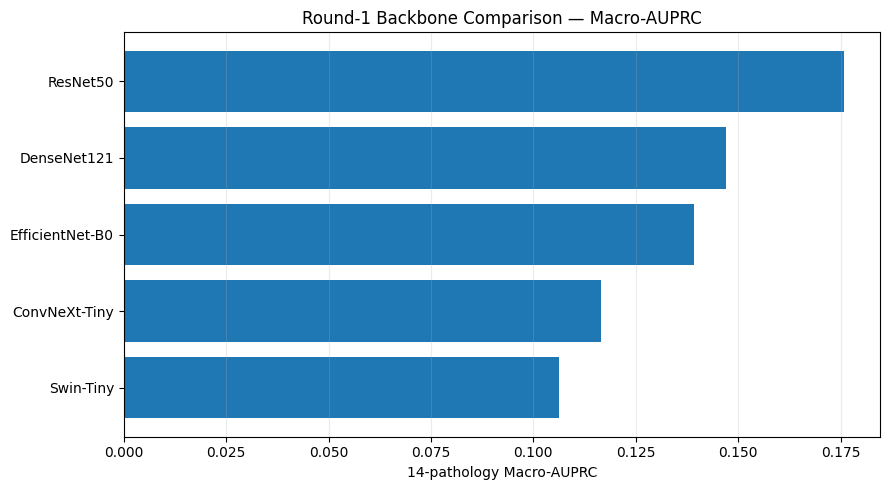

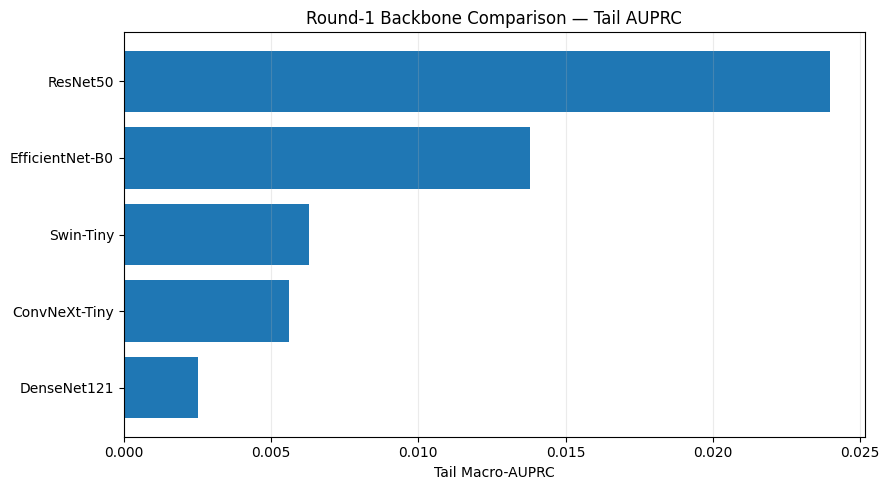

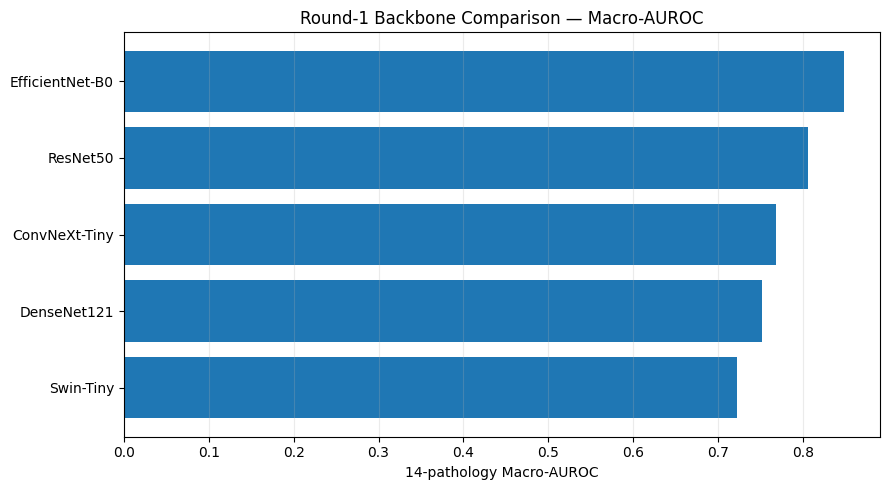

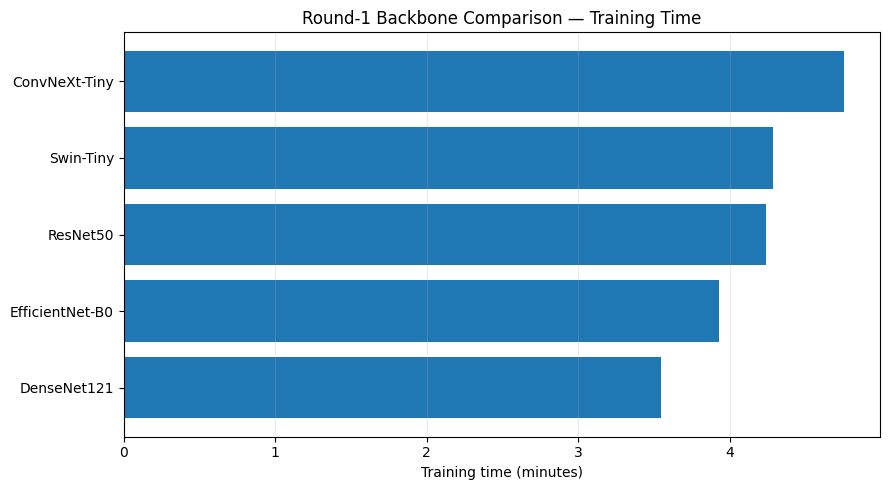

In [7]:
# ============================================================
# 7. Comparison figures
# ============================================================
plot_df = comparison.sort_values("macro_AUPRC_14", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["backbone"], plot_df["macro_AUPRC_14"])
ax.set_xlabel("14-pathology Macro-AUPRC")
ax.set_title("Round-1 Backbone Comparison — Macro-AUPRC")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "baseline_macro_auprc_comparison.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

plot_df = comparison.sort_values("tail_macro_AUPRC", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["backbone"], plot_df["tail_macro_AUPRC"])
ax.set_xlabel("Tail Macro-AUPRC")
ax.set_title("Round-1 Backbone Comparison — Tail AUPRC")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "baseline_tail_auprc_comparison.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

plot_df = comparison.sort_values("macro_AUROC_14", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["backbone"], plot_df["macro_AUROC_14"])
ax.set_xlabel("14-pathology Macro-AUROC")
ax.set_title("Round-1 Backbone Comparison — Macro-AUROC")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "baseline_macro_auroc_comparison.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

plot_df = comparison.sort_values("training_minutes", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["backbone"], plot_df["training_minutes"])
ax.set_xlabel("Training time (minutes)")
ax.set_title("Round-1 Backbone Comparison — Training Time")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "baseline_training_time_comparison.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()


In [8]:
# ============================================================
# 8. Generate research summary
# ============================================================
best_primary = comparison.sort_values(
    "macro_AUPRC_14", ascending=False
).iloc[0]

best_tail = comparison.sort_values(
    "tail_macro_AUPRC", ascending=False
).iloc[0]

best_auroc = comparison.sort_values(
    "macro_AUROC_14", ascending=False
).iloc[0]

lines = [
    "Pedi-CGAM Lite — Stage 04 Baseline Comparison",
    "=" * 60,
    "",
    "FAIRNESS",
    "- All five backbones used the same frozen Stage 02 split.",
    "- All used 224x224, BCE, batch size 16, seed 42.",
    "- Calibration and official test were not used.",
    "",
    "BEST ROUND-1 RESULTS",
    (
        f"- Highest 14-pathology Macro-AUPRC: "
        f"{best_primary['backbone']} "
        f"({best_primary['macro_AUPRC_14']:.6f})"
    ),
    (
        f"- Highest Tail Macro-AUPRC: "
        f"{best_tail['backbone']} "
        f"({best_tail['tail_macro_AUPRC']:.6f})"
    ),
    (
        f"- Highest 14-pathology Macro-AUROC: "
        f"{best_auroc['backbone']} "
        f"({best_auroc['macro_AUROC_14']:.6f})"
    ),
    "",
    "STRICT PRIMARY-METRIC TOP TWO",
]

for _, r in strict_top2.iterrows():
    lines.append(
        f"- {r['backbone']}: Macro-AUPRC={r['macro_AUPRC_14']:.6f}"
    )

lines += [
    "",
    "PROJECT-ALIGNED ROUND-2 FINALISTS",
    "- ResNet50",
    "- EfficientNet-B0",
    "",
    "RATIONALE",
    (
        "- ResNet50 is the clear Round-1 leader on the primary "
        "Macro-AUPRC and also has the strongest tail result."
    ),
    (
        "- DenseNet121 ranks second on primary Macro-AUPRC, but "
        "EfficientNet-B0 is kept as the second Round-2 finalist because "
        "its Macro-AUPRC is close while its tail AUPRC, Macro-AUROC, "
        "fixed-threshold F1/sensitivity, and GPU efficiency are stronger."
    ),
    (
        "- Swin-Tiny remains a useful transformer baseline in the paper, "
        "but its Round-1 result does not justify advancing it to Round 2."
    ),
    "",
    "CAUTION",
    (
        "- Ultra-rare validation classes have very few positives, so "
        "small per-class and tail differences must not be overinterpreted."
    ),
    (
        "- This screening selects candidates for a higher-resolution "
        "320x320 comparison; it is not the final model conclusion."
    ),
]

summary_text = "\n".join(lines)
print(summary_text)

(OUTPUT_DIR / "README_STAGE04_RESULTS.txt").write_text(summary_text)

selection = {
    "strict_top2_by_macro_auprc": strict_top2[
        "experiment_id"
    ].tolist(),
    "recommended_round2_finalists": RECOMMENDED_FINALISTS,
    "selection_policy": (
        "Primary Macro-AUPRC plus long-tail performance, Macro-AUROC, "
        "fixed-threshold behavior, stability, and GPU efficiency."
    ),
    "official_test_used": False,
    "calibration_used": False,
}

(OUTPUT_DIR / "round2_selection.json").write_text(
    json.dumps(selection, indent=2)
)


Pedi-CGAM Lite — Stage 04 Baseline Comparison

FAIRNESS
- All five backbones used the same frozen Stage 02 split.
- All used 224x224, BCE, batch size 16, seed 42.
- Calibration and official test were not used.

BEST ROUND-1 RESULTS
- Highest 14-pathology Macro-AUPRC: ResNet50 (0.175837)
- Highest Tail Macro-AUPRC: ResNet50 (0.023966)
- Highest 14-pathology Macro-AUROC: EfficientNet-B0 (0.848101)

STRICT PRIMARY-METRIC TOP TWO
- ResNet50: Macro-AUPRC=0.175837
- DenseNet121: Macro-AUPRC=0.147094

PROJECT-ALIGNED ROUND-2 FINALISTS
- ResNet50
- EfficientNet-B0

RATIONALE
- ResNet50 is the clear Round-1 leader on the primary Macro-AUPRC and also has the strongest tail result.
- DenseNet121 ranks second on primary Macro-AUPRC, but EfficientNet-B0 is kept as the second Round-2 finalist because its Macro-AUPRC is close while its tail AUPRC, Macro-AUROC, fixed-threshold F1/sensitivity, and GPU efficiency are stronger.
- Swin-Tiny remains a useful transformer baseline in the paper, but its Round

372

In [9]:
# ============================================================
# 9. Final integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check": "All 5 experiments discovered",
        "passed": len(discovered) == 5,
    },
    {
        "check": "All fairness checks passed",
        "passed": verification_df["all_fairness_checks_pass"].all(),
    },
    {
        "check": "All primary metrics finite",
        "passed": np.isfinite(comparison["macro_AUPRC_14"]).all(),
    },
    {
        "check": "All tail metrics finite",
        "passed": np.isfinite(comparison["tail_macro_AUPRC"]).all(),
    },
    {
        "check": "Round-2 finalists recorded",
        "passed": len(RECOMMENDED_FINALISTS) == 2,
    },
])

checks["status"] = checks["passed"].map(
    {True: "PASS", False: "REVIEW"}
)

display(checks)
checks.to_csv(
    OUTPUT_DIR / "stage04_final_status.csv",
    index=False
)

FINAL_STATUS = "PASS" if checks["passed"].all() else "REVIEW"

print("\n" + "=" * 70)
print("STAGE 04 FINAL STATUS:", FINAL_STATUS)
if FINAL_STATUS == "PASS":
    print("✅ ROUND-1 BASELINE COMPARISON COMPLETE")
    print("Recommended Round-2 finalists: ResNet50 + EfficientNet-B0")
else:
    print("⚠️ REVIEW BEFORE STARTING ROUND 2")
print("=" * 70)


,check,passed,status
0,All 5 experiments discovered,True,PASS
1,All fairness checks passed,True,PASS
2,All primary metrics finite,True,PASS
3,All tail metrics finite,True,PASS
4,Round-2 finalists recorded,True,PASS



STAGE 04 FINAL STATUS: PASS
✅ ROUND-1 BASELINE COMPARISON COMPLETE
Recommended Round-2 finalists: ResNet50 + EfficientNet-B0


In [10]:
# ============================================================
# 10. ZIP all Stage 04 outputs
# ============================================================
ZIP_BASE = Path(
    "/kaggle/working/PediCGAM_Stage04_Baseline_Comparison_All_Outputs"
)
ZIP_FILE = Path(str(ZIP_BASE) + ".zip")

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(OUTPUT_DIR)
)

print("✅ STAGE 04 ZIP CREATED")
print("File:", ZIP_FILE)
print(f"Size: {ZIP_FILE.stat().st_size/(1024**2):.2f} MB")
print("\nDownload this one ZIP from Kaggle Output.")


✅ STAGE 04 ZIP CREATED
File: /kaggle/working/PediCGAM_Stage04_Baseline_Comparison_All_Outputs.zip
Size: 0.17 MB

Download this one ZIP from Kaggle Output.


## Next stage

If Stage 04 is `PASS`, freeze the Round-1 comparison.

The proposed Round-2 notebooks are:

- `05A_Final_Backbone_ResNet50_320.ipynb`
- `05B_Final_Backbone_EfficientNetB0_320.ipynb`
- `05C_Final_Backbone_Comparison.ipynb`

Round 2 will use **320×320** images while keeping the frozen split and the rest of the comparison protocol controlled.
